In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv("netflix_titles.csv", encoding="latin-1") 
#This file is NOT encoded in UTF-8 (Unicode Transformation Format – standard text encoding). so encoding="latin-1" is used to catch any
#weird characters
df = df.loc[:,~df.columns.str.contains('^Unnamed')] #this remove columns with "Unnamed" in their name


(8809, 12)

In [115]:
#to read the dataset
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,duration_type,main_genre,is_movie
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,m,Documentaries,1
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,S,International TV Shows,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,S,Crime TV Shows,0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,S,Docuseries,0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,S,International TV Shows,0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1.0,S,TV Dramas,0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, JosÃ© Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,m,Children & Family Movies,1
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,m,Dramas,1
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9.0,S,British TV Shows,0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,m,Comedies,1


# FIRST INSPECTION OF DATA

In [99]:
df.describe() #released yeaar is the only statuistical data

,release_year,duration_int,is_movie
count,8796.000000,8796.000000,8796.000000
mean,2014.184629,69.916894,0.696794
std,8.823145,50.798343,0.459670
min,1925.000000,1.000000,0.000000
25%,2013.000000,2.000000,0.000000
50%,2017.000000,88.000000,1.000000
75%,2019.000000,106.000000,1.000000
max,2024.000000,312.000000,1.000000


In [100]:
df.info()
#(8809, 12) #rows,colum

<class 'pandas.core.frame.DataFrame'>
Index: 8796 entries, 0 to 8808
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   show_id        8796 non-null   object 
 1   type           8796 non-null   object 
 2   title          8796 non-null   object 
 3   director       6172 non-null   object 
 4   cast           7971 non-null   object 
 5   country        7966 non-null   object 
 6   date_added     8796 non-null   object 
 7   release_year   8796 non-null   int64  
 8   rating         8796 non-null   object 
 9   duration       8796 non-null   object 
 10  listed_in      8796 non-null   object 
 11  description    8796 non-null   object 
 12  duration_int   8796 non-null   float64
 13  duration_type  8796 non-null   object 
 14  main_genre     8796 non-null   object 
 15  is_movie       8796 non-null   int64  
dtypes: float64(1), int64(2), object(13)
memory usage: 1.1+ MB


In [101]:
df.isnull().sum() #to count missing values per column
#strong columns - show_id,type,title,description, rating and lsited_in
#weak colummns - director,country annd cast

show_id             0
type                0
title               0
director         2624
cast              825
country           830
date_added          0
release_year        0
rating              0
duration            0
listed_in           0
description         0
duration_int        0
duration_type       0
main_genre          0
is_movie            0
dtype: int64

# DATA CLEANING

In [102]:
#Handle missing values -->fill abd analyze impact of crirical and drop non critial

In [103]:
df["rating"] = df["rating"].fillna("Unknown") #filling the ratings with unknown
df = df.dropna(subset=["duration","date_added"]) #drop rows with both empty
df.isnull().sum() 

show_id             0
type                0
title               0
director         2624
cast              825
country           830
date_added          0
release_year        0
rating              0
duration            0
listed_in           0
description         0
duration_int        0
duration_type       0
main_genre          0
is_movie            0
dtype: int64

In [104]:
#duration problem -to split
df["duration_int"] = df["duration"].str.extract('(\d+)').astype(float) #numeric analysus
df["duration_type"] = df["duration"].str.extract('([a-zA-Z+])') #movies vs TV logcid


# Feature engineering

In [105]:
#to extract the main genre - note list_in =genre
df["main_genre"] = df["listed_in"].str.split(',').str[0] #SIMPLIFY MUltiple genre for analysis
df["main_genre"]

0                  Documentaries
1         International TV Shows
2                 Crime TV Shows
3                     Docuseries
4         International TV Shows
                  ...           
8804                    Comedies
8805    Children & Family Movies
8806                      Dramas
8807                      Sci-fi
8808                       Drama
Name: main_genre, Length: 8796, dtype: object

In [106]:
#content type encodeing
df["is_movie"] = df["type"].apply(lambda x : 1 if x=="Movie" else 0)
df["is_movie"] 

0       1
1       0
2       0
3       0
4       0
       ..
8804    1
8805    1
8806    1
8807    0
8808    1
Name: is_movie, Length: 8796, dtype: int64

# EDA - 

In [107]:
#which genre dominates
df["main_genre"].value_counts().head(10)

main_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     386
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

In [117]:
#movies vs tv shows
df["type"].value_counts().head(10)

type
Movie      6129
TV Show    2667
Name: count, dtype: int64

In [137]:
#content over time
df["release_year"].value_counts().sort_index()

release_year
2018    1146
2017    1031
2019    1030
2020     953
2016     901
        ... 
1959       1
1925       1
1961       1
1947       1
2024       1
Name: count, Length: 75, dtype: int64

In [118]:
#country with the most place produced
df["country"].value_counts().head(10)

country
United States     2810
India              972
United Kingdom     418
Japan              244
South Korea        200
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [129]:
#ratings VS main_genre
#grouping
pivot = pd.pivot_table(
    df,
    index = "main_genre",
    columns = "rating",
    aggfunc = "size",
    fill_value = 0
)
pivot.head(3)


rating,A,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR,Unknown
main_genre,,,,,,,,,,,,,,,,
Action & Adventure,0,1,0,9,32,148,220,213,0,201,33,0,0,1,1,0
Anime Features,0,0,0,0,4,2,0,3,1,1,6,0,4,0,0,0
Anime Series,0,0,0,0,0,0,0,70,0,59,17,2,26,0,0,1


In [128]:
#to normalize
pivot_normalize = pivot.div(pivot.sum(axis=1),axis=0)
pivot_normalize.head(3)

rating,A,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR,Unknown
main_genre,,,,,,,,,,,,,,,,
Action & Adventure,0.0,0.001164,0.0,0.010477,0.037253,0.172293,0.256112,0.247963,0.000000,0.233993,0.038417,0.000000,0.000000,0.001164,0.001164,0.000000
Anime Features,0.0,0.000000,0.0,0.000000,0.190476,0.095238,0.000000,0.142857,0.047619,0.047619,0.285714,0.000000,0.190476,0.000000,0.000000,0.000000
Anime Series,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.337143,0.097143,0.011429,0.148571,0.000000,0.000000,0.005714


#  VISUALIZATION

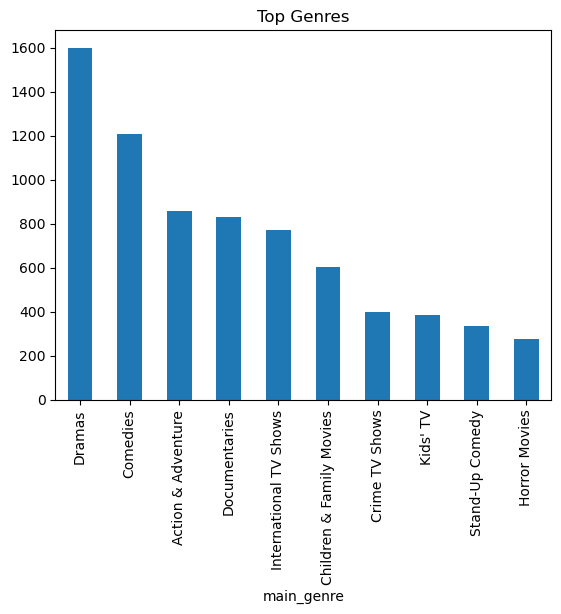

In [131]:
#Genre distribution
df["main_genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top Genres")
plt.show()

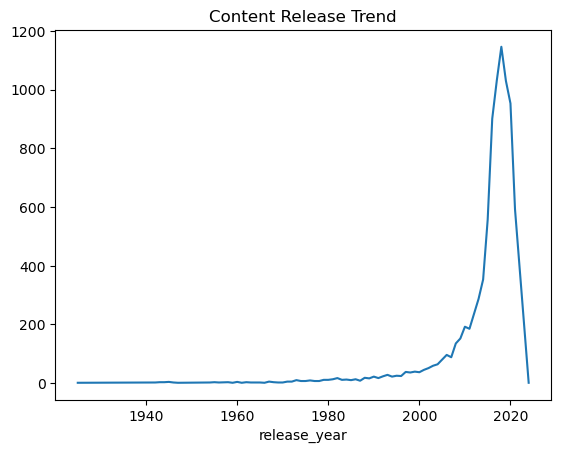

In [132]:
#content groeth over time
df["release_year"].value_counts().sort_index().plot(kind="line")
plt.title("Content Release Trend")
plt.show()

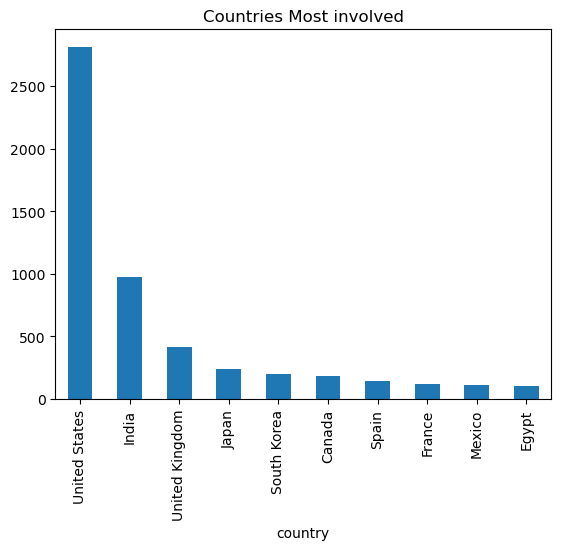

In [139]:
#countries most involved
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Countries Most involved")
plt.show()

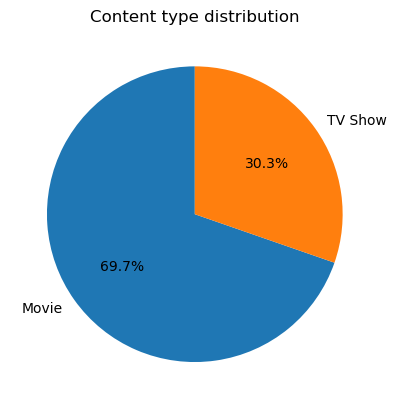

In [145]:
#Content type distribution
type_counts = df["type"].value_counts()
plt.figure()
type_counts.plot(kind = "pie",startangle = 90, autopct = "%1.1f%%" )
plt.ylabel('')
plt.title("Content type distribution")
plt.show()
    

# INSIGHTS

In [ ]:
"""
1.Drama and Comedies - heavy catalog suggests over-reliance and opportunity to diversify into under represented gigh demand genres
2.The above Data analysis shows peak release at 2018 (with 1146 release) then a steady decline over the following years and high dependence
in united states for production and activities. 
3.From the charts the platform is dominated by Movies(69.7%) comparred to TV shows(30.3%)
"""